In [4]:
#phase 1
#(s1-2)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw tables
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("reviews:", reviews.shape)
print("products:", products.shape)

orders: (99441, 8)
order_items: (112650, 7)
reviews: (99224, 7)
products: (32951, 9)


In [5]:
print(orders.columns.tolist())
print(order_items.columns.tolist())
print(reviews.columns.tolist())
print(products.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [6]:
#(s3)

# Merge orders with reviews (bring in review_score)
df = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Merge with order items to get product_id, then products to get category
df = df.merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# Convert date columns to actual datetime objects
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Delivery delay in days: positive = delivered later than estimated
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# The return-proxy: 1 if review score is 1 or 2, OR order was cancelled
df['is_return_proxy'] = ((df['review_score'] <= 2) | (df['order_status'] == 'canceled')).astype(int)

# Sanity check
print(df['is_return_proxy'].value_counts(normalize=True))
print(df.shape)

is_return_proxy
0    0.834458
1    0.165542
Name: proportion, dtype: float64
(114092, 13)


In [7]:
# Step 4 (fixed): one row per distinct order before summing return-proxy flags

df['week'] = df['order_purchase_timestamp'].dt.to_period('W').dt.start_time

# Collapse multi-item duplicates down to one row per order
orders_weekly = df.drop_duplicates(subset='order_id')[['order_id', 'week', 'is_return_proxy', 'delivery_delay_days']]

weekly = orders_weekly.groupby('week').agg(
    total_orders=('order_id', 'nunique'),
    total_return_proxy=('is_return_proxy', 'sum'),
    avg_delivery_delay=('delivery_delay_days', 'mean')
).reset_index()

weekly['return_rate'] = weekly['total_return_proxy'] / weekly['total_orders']

print(weekly.shape)
weekly.head(10)

(101, 5)


,week,total_orders,total_return_proxy,avg_delivery_delay,return_rate
0,2016-08-29,1,1,NaN,1.000000
1,2016-09-05,1,1,NaN,1.000000
2,2016-09-12,2,2,36.000000,1.000000
3,2016-09-26,1,1,NaN,1.000000
4,2016-10-03,283,85,-36.533898,0.300353
5,2016-10-10,39,8,-37.529412,0.205128
6,2016-10-17,1,1,NaN,1.000000
7,2016-12-19,1,0,-22.000000,0.000000
8,2017-01-02,46,4,-25.636364,0.086957
9,2017-01-09,80,16,-25.917808,0.200000


In [8]:
# Check low volume weeks , which may cause issue thus removing them 
low_volume_weeks = weekly[weekly['total_orders'] < 100][['week', 'total_orders']]
print(low_volume_weeks)

          week  total_orders
0   2016-08-29             1
1   2016-09-05             1
2   2016-09-12             2
3   2016-09-26             1
5   2016-10-10            39
6   2016-10-17             1
7   2016-12-19             1
8   2017-01-02            46
9   2017-01-09            80
95  2018-09-03             7
96  2018-09-10             4
97  2018-09-17             2
98  2018-09-24             3
99  2018-10-01             2
100 2018-10-15             2


In [9]:
# --- Fill in any missing weeks (weeks with 0 orders don't get a row from groupby) ---
full_weeks = pd.date_range(start=weekly['week'].min(), end=weekly['week'].max(), freq='W-MON')

weekly_full = weekly.set_index('week').reindex(full_weeks)
weekly_full.index.name = 'week'
weekly_full = weekly_full.reset_index()

weekly_full['total_orders'] = weekly_full['total_orders'].fillna(0)
weekly_full['total_return_proxy'] = weekly_full['total_return_proxy'].fillna(0)
weekly_full['return_rate'] = weekly_full['return_rate'].fillna(0)
weekly_full['avg_delivery_delay'] = weekly_full['avg_delivery_delay'].ffill()

print("Full gap-filled shape:", weekly_full.shape)
print("\nWeeks that were originally missing (0 orders):")
print(weekly_full[weekly_full['total_orders'] == 0])

# --- Trim unreliable low-volume weeks (ramp-up / tail-off) ---
weekly_clean = weekly_full[weekly_full['total_orders'] >= 100].reset_index(drop=True)

# --- Also drop the last week (2018-08-27) — confirmed via plot as a partial/cutoff week ---
weekly_clean = weekly_clean[weekly_clean['week'] < '2018-08-27'].reset_index(drop=True)

print("\nFinal cleaned shape:", weekly_clean.shape)
weekly_clean

Full gap-filled shape: (112, 5)

Weeks that were originally missing (0 orders):
          week  total_orders  total_return_proxy  avg_delivery_delay  \
3   2016-09-19           0.0                 0.0           36.000000   
8   2016-10-24           0.0                 0.0          -37.529412   
9   2016-10-31           0.0                 0.0          -37.529412   
10  2016-11-07           0.0                 0.0          -37.529412   
11  2016-11-14           0.0                 0.0          -37.529412   
12  2016-11-21           0.0                 0.0          -37.529412   
13  2016-11-28           0.0                 0.0          -37.529412   
14  2016-12-05           0.0                 0.0          -37.529412   
15  2016-12-12           0.0                 0.0          -37.529412   
17  2016-12-26           0.0                 0.0          -22.000000   
110 2018-10-08           0.0                 0.0           -5.275862   

     return_rate  
3            0.0  
8            0.0 

,week,total_orders,total_return_proxy,avg_delivery_delay,return_rate
0,2016-10-03,283.0,85.0,-36.533898,0.300353
1,2017-01-16,197.0,25.0,-28.798942,0.126904
2,2017-01-23,354.0,61.0,-27.072289,0.172316
3,2017-01-30,467.0,71.0,-23.930556,0.152034
4,2017-02-06,548.0,70.0,-20.641879,0.127737
...,...,...,...,...,...
80,2018-07-23,1646.0,169.0,-10.632919,0.102673
81,2018-07-30,2058.0,286.0,-7.276723,0.138970
82,2018-08-06,1988.0,251.0,-7.713102,0.126258
83,2018-08-13,1875.0,163.0,-9.223491,0.086933


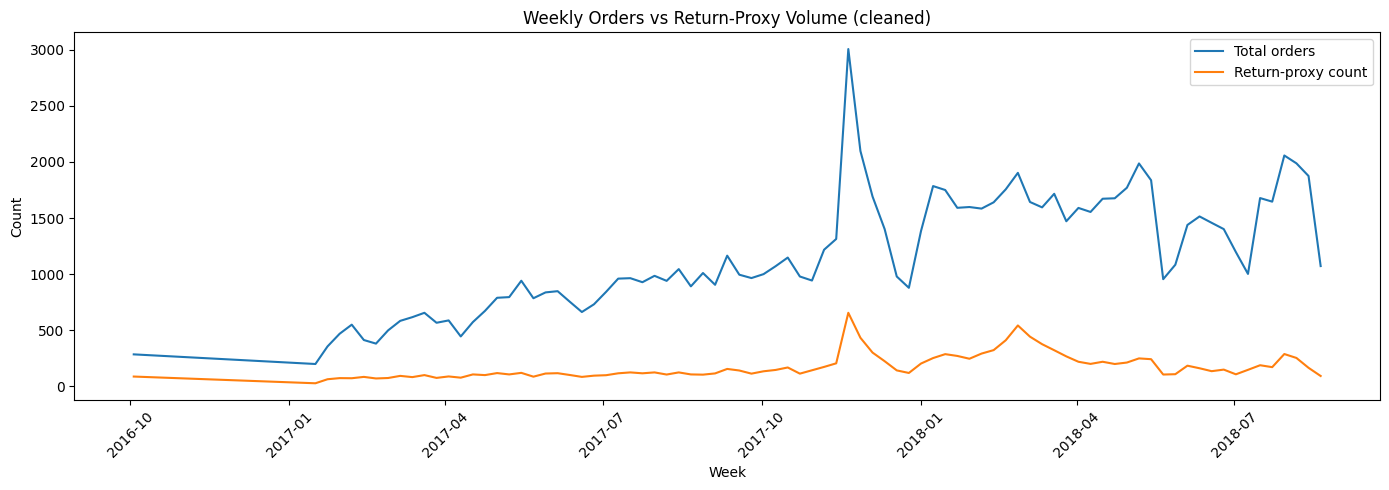

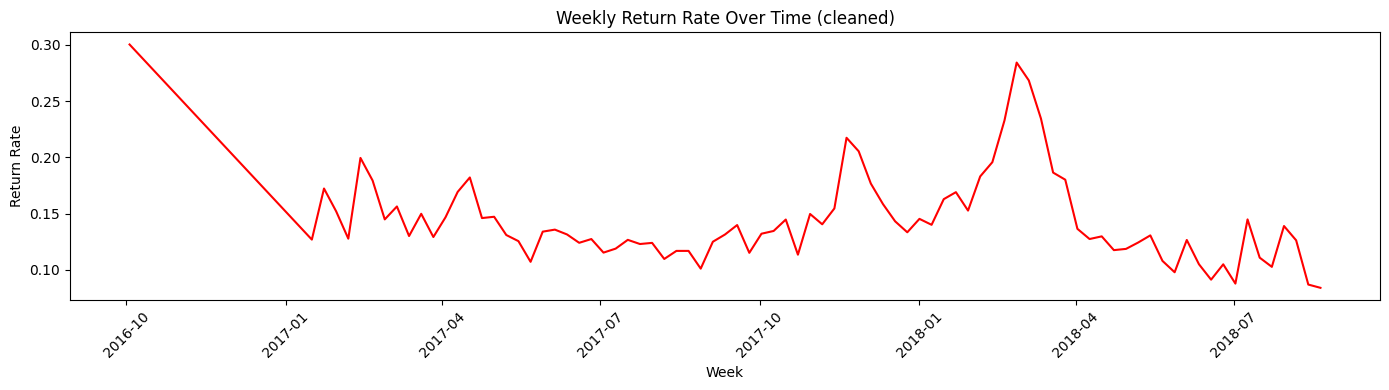

In [11]:
plt.figure(figsize=(14,5))
plt.plot(weekly_clean['week'], weekly_clean['total_orders'], label='Total orders')
plt.plot(weekly_clean['week'], weekly_clean['total_return_proxy'], label='Return-proxy count')
plt.title('Weekly Orders vs Return-Proxy Volume (cleaned)')
plt.xlabel('Week')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(weekly_clean['week'], weekly_clean['return_rate'], color='red')
plt.title('Weekly Return Rate Over Time (cleaned)')
plt.xlabel('Week')
plt.ylabel('Return Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Save cleaned output to data/processed/
weekly_clean.to_csv('../data/processed/weekly_clean.csv', index=False)

#### Phase 1 summary: Loaded and merged Olist's order, review, item, and product tables into one dataset, built a "return-proxy" label from review scores/cancellations, then aggregated it into a clean, gap-free, noise-trimmed weekly time series ready for forecasting.

#### Final output: weekly_clean(dataset) — 85 weeks (Oct 2016–Aug 2018) with total_orders, total_return_proxy, avg_delivery_delay, and return_rate per week.